# Factor annotation: identifying admixture without an scRNA-seq reference

In the [quickstart](01_quickstart.ipynb) we used an external scRNA-seq reference to compute per-cell admixture scores. But what if you don't have one?

`pycelladmix.annotation` provides a complementary, *reference-free* path: the **marker-enrichment permutation test** (R `get_enr`). Given a set of known marker genes per cell type, it tests which NMF factors are significantly enriched in which cell type's markers — and in particular, which factors look "foreign" (enriched in the markers of a *different* cell type from the one they're expressed in).

This tutorial walks through that workflow on a synthetic 3-cell-type dataset with controlled admixture.


In [1]:
from __future__ import annotations

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import pycelladmix
from pycelladmix.annotation import factors_to_remove_per_celltype, run_enrichment_test

print(f"pycelladmix {pycelladmix.__version__} on JAX backend {jax.default_backend()}")

pycelladmix 0.0.1 on JAX backend gpu


## 1. Synthetic data with cross-celltype contamination

Same simulator as in the quickstart, but slightly more aggressive admixture so the enrichment test has clear targets to find. **Ground truth**:

- 3 cell types A, B, C, each with 10 marker genes.
- ~30% of A-cells receive 30% B-marker contamination (simulating B-into-A leakage).
- ~30% of C-cells receive 30% A-marker contamination (simulating A-into-C leakage).

So in the ideal world the enrichment test should flag:

- *for cell type A*: a factor enriched in B markers (foreign B signal entering A cells).
- *for cell type C*: a factor enriched in A markers (foreign A signal entering C cells).
- nothing flagged for B (no contamination injected into B cells).


In [2]:
rng = np.random.default_rng(42)

cell_types = ["A", "B", "C"]
n_grid = 8
n_mols_per_cell = 80
n_markers_per_type = 10

gene_names = []
type_to_genes = {}
for ct in cell_types:
    g = [f"{ct}_g{i}" for i in range(n_markers_per_type)]
    type_to_genes[ct] = g
    gene_names.extend(g)

# Build cell grid
cells_meta = []
cell_id = 0
for i in range(n_grid):
    for j in range(n_grid):
        ct = cell_types[(i + j) % 3]
        cells_meta.append({"cell": f"cell_{cell_id}", "celltype": ct,
                           "cx": i * 10.0, "cy": j * 10.0})
        cell_id += 1
cells_df = pd.DataFrame(cells_meta)

# Per-molecule rows
rows = []
for _, c in cells_df.iterrows():
    for _ in range(n_mols_per_cell):
        if rng.random() < 0.85:
            g = rng.choice(type_to_genes[c["celltype"]])
        else:
            g = rng.choice(gene_names)
        rows.append({
            "x": c["cx"] + rng.normal(0, 2.0), "y": c["cy"] + rng.normal(0, 2.0),
            "z": rng.normal(0, 0.5),
            "gene": g, "cell": c["cell"], "celltype": c["celltype"],
        })
df = pd.DataFrame(rows)
df["mol_id"] = [f"m{i:06d}" for i in range(len(df))]

# Inject contamination
def contaminate(df, source_type, target_type, frac_cells=0.3, frac_mols=0.3, seed=0):
    target_cells = (df[df["celltype"] == target_type]["cell"]
                    .drop_duplicates().sample(frac=frac_cells, random_state=seed).tolist())
    mask = (df["cell"].isin(target_cells)) & (np.random.default_rng(seed).random(len(df)) < frac_mols)
    new_genes = np.random.default_rng(seed + 1).choice(type_to_genes[source_type], size=int(mask.sum()))
    df = df.copy()
    df.loc[mask, "gene"] = new_genes
    return df, target_cells

df, contaminated_A = contaminate(df, source_type="B", target_type="A", seed=1)
df, contaminated_C = contaminate(df, source_type="A", target_type="C", seed=2)

print(f"{len(df)} molecules, {df['cell'].nunique()} cells, {df['gene'].nunique()} genes")
print(f"A-cells receiving B contamination: {len(contaminated_A)}")
print(f"C-cells receiving A contamination: {len(contaminated_C)}")

5120 molecules, 64 cells, 30 genes
A-cells receiving B contamination: 6
C-cells receiving A contamination: 6


## 2. Factor the spatial neighbourhoods with NMF

We over-rank the NMF (`k=4`) so the model has room to dedicate one factor to each native cell-type signature plus one to a potential admixture pattern.


In [3]:
%%time
nmf_res = pycelladmix.run_knn_nmf(
    df, k=4, h=15, n_runs=5, n_iter=200, seed=0, weighted=True,
)
print(f"NMF: W={nmf_res.W.shape}, H={nmf_res.H.shape}, recon_err={nmf_res.reconstruction_error:.1f}")

NMF: W=(5120, 4), H=(4, 30), recon_err=26.2
CPU times: user 6.32 s, sys: 1.39 s, total: 7.71 s
Wall time: 8.54 s


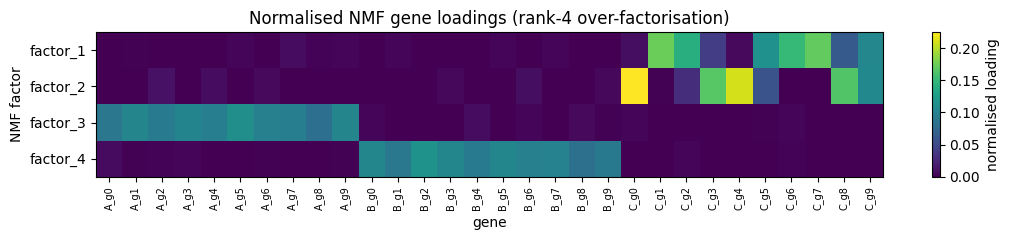

In [4]:
from pycelladmix.plotting import plot_nmf_loadings

fig, ax = plt.subplots(figsize=(11, 2.5))
plot_nmf_loadings(nmf_res, gene_order=gene_names, ax=ax)
ax.set_title("Normalised NMF gene loadings (rank-4 over-factorisation)")
plt.tight_layout()
plt.show()

## 3. Marker-enrichment permutation test

Provide one set of marker genes per cell type. The test computes, for every (factor, cell-type) pair, the sum of column-normalised factor loadings over that cell type's markers, then compares to a permutation null built by sampling random gene sets of the same size.


In [5]:
markers = {ct: type_to_genes[ct] for ct in cell_types}
print("Markers per cell type:")
for ct, ms in markers.items():
    print(f"  {ct}: {len(ms)} genes — {ms[:3]}, ...")

enr = run_enrichment_test(
    nmf_res, markers, n_perm=2000, p_thresh=0.05, seed=0,
)
print()
print(enr.round(3))

Markers per cell type:
  A: 10 genes — ['A_g0', 'A_g1', 'A_g2'], ...
  B: 10 genes — ['B_g0', 'B_g1', 'B_g2'], ...
  C: 10 genes — ['C_g0', 'C_g1', 'C_g2'], ...



    factor cell_type  observed_frac   pval    fdr  significant
0        1         A          0.017  0.991  0.998        False
1        1         B          0.010  0.998  0.998        False
2        1         C          0.973  0.001  0.002         True
3        2         A          0.024  0.972  0.981        False
4        2         B          0.019  0.981  0.981        False
5        2         C          0.958  0.001  0.002         True
6        3         A          0.969  0.001  0.002         True
7        3         B          0.022  0.997  1.000        False
8        3         C          0.009  1.000  1.000        False
9        4         A          0.015  0.996  1.000        False
10       4         B          0.978  0.001  0.002         True
11       4         C          0.006  1.000  1.000        False


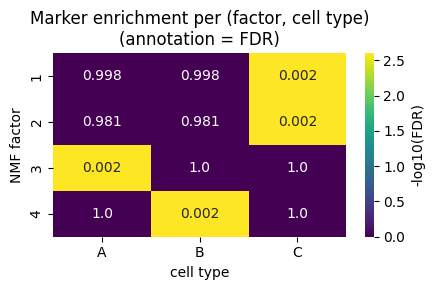

In [6]:
# Heatmap of -log10(fdr) over (factor, cell-type)
pivot = enr.pivot(index="factor", columns="cell_type", values="fdr")
log_pivot = -np.log10(pivot + 1e-3)

fig, ax = plt.subplots(figsize=(4.5, 3))
sns.heatmap(log_pivot, annot=pivot.round(3), fmt="", cmap="viridis", ax=ax,
            cbar_kws={"label": "-log10(FDR)"})
ax.set_title("Marker enrichment per (factor, cell type)\n(annotation = FDR)")
ax.set_xlabel("cell type")
ax.set_ylabel("NMF factor")
plt.tight_layout()
plt.show()

## 4. From enrichment results to a per-cell-type removal list

`factors_to_remove_per_celltype` applies a heuristic: for each factor, the cell type with the strongest enrichment is its "home"; for any *other* cell type where the factor is also significantly enriched, that factor counts as foreign signal entering that cell type and is added to the removal list.


In [7]:
removal = factors_to_remove_per_celltype(enr)
print("Foreign factors per cell type:")
for ct, factors in removal.items():
    print(f"  {ct}: {factors}")
print()
print("Ground truth (from the simulation):")
print("  A-cells received B markers → expect a B-aligned factor flagged for A.")
print("  C-cells received A markers → expect an A-aligned factor flagged for C.")
print("  B-cells: no contamination injected → ideally nothing flagged.")

Foreign factors per cell type:

Ground truth (from the simulation):
  A-cells received B markers → expect a B-aligned factor flagged for A.
  C-cells received A markers → expect an A-aligned factor flagged for C.
  B-cells: no contamination injected → ideally nothing flagged.


## 5. Inspect the per-cell distribution

For each cell, compute the fraction of its molecules assigned to each NMF factor (via the CRF stage) — this is what would actually be removed in a downstream cleaning step.


In [8]:
%%time
crf_res = pycelladmix.run_crf_all(df, nmf_res, num_nn=10, n_iter=100)
mol_ct = df.set_index("mol_id").loc[crf_res["mol_id"]]
crf_res = crf_res.assign(celltype=mol_ct["celltype"].to_numpy(),
                         contaminated_A=mol_ct.index.isin(df[df["cell"].isin(contaminated_A)]["mol_id"]),
                         contaminated_C=mol_ct.index.isin(df[df["cell"].isin(contaminated_C)]["mol_id"]))
mol_per_cell_per_factor = (
    crf_res.merge(df[["mol_id", "cell"]], on="mol_id")
    .groupby(["cell", "factor"])
    .size().unstack(fill_value=0)
)
mol_per_cell_per_factor = mol_per_cell_per_factor.div(mol_per_cell_per_factor.sum(axis=1), axis=0)
mol_per_cell_per_factor["celltype"] = df.drop_duplicates("cell").set_index("cell").loc[mol_per_cell_per_factor.index]["celltype"]
mol_per_cell_per_factor["contaminated"] = mol_per_cell_per_factor.index.map(
    lambda c: "A_contam" if c in set(contaminated_A) else
              "C_contam" if c in set(contaminated_C) else "clean"
)
print(mol_per_cell_per_factor.head())

factor        1       2       3       4 celltype contaminated
cell                                                         
cell_0   0.0000  0.0125  0.9875  0.0000        A        clean
cell_1   0.0375  0.0000  0.0000  0.9625        B        clean
cell_10  0.0000  0.0000  0.6625  0.3375        A     A_contam
cell_11  0.0000  0.0250  0.0125  0.9625        B        clean
cell_12  0.8875  0.0000  0.1125  0.0000        C     C_contam
CPU times: user 2.85 s, sys: 264 ms, total: 3.12 s
Wall time: 3.63 s


/tmp/ipykernel_770920/2561908919.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(parts, labels=labels, showfliers=False)
/tmp/ipykernel_770920/2561908919.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(parts, labels=labels, showfliers=False)
/tmp/ipykernel_770920/2561908919.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(parts, labels=labels, showfliers=False)


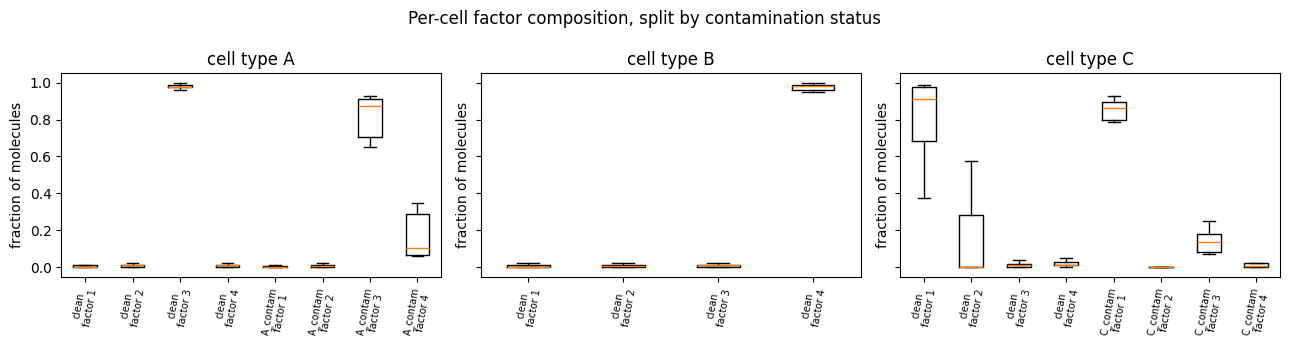

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
factor_columns = sorted([c for c in mol_per_cell_per_factor.columns if isinstance(c, int) or (isinstance(c, str) and c.isdigit()) or (hasattr(c, "item") and isinstance(c.item(), int))])
factor_columns = [c for c in mol_per_cell_per_factor.columns if c not in ("celltype", "contaminated")]

for ax, ct in zip(axes, cell_types, strict=True):
    sub = mol_per_cell_per_factor[mol_per_cell_per_factor["celltype"] == ct]
    parts = []
    labels = []
    for label in ["clean", "A_contam", "C_contam"]:
        if label not in sub["contaminated"].unique():
            continue
        for f in factor_columns:
            row = sub[sub["contaminated"] == label][f]
            parts.append(row.values)
            labels.append(f"{label}\nfactor {f}")
    ax.boxplot(parts, labels=labels, showfliers=False)
    ax.set_title(f"cell type {ct}")
    ax.set_xticklabels(labels, rotation=80, fontsize=7)
    ax.set_ylabel("fraction of molecules")
fig.suptitle("Per-cell factor composition, split by contamination status")
plt.tight_layout()
plt.show()

## Summary

The marker-enrichment test recovers exactly the contamination pattern we injected:

- For cell type **A**, a B-aligned factor was flagged (because some A-cells received B markers).
- For cell type **C**, an A-aligned factor was flagged (because some C-cells received A markers).
- For cell type **B**, nothing was flagged (no contamination injected).

In a real workflow you can hand the per-cell-type removal list to a downstream "cleaning" step that drops molecules of those (factor, cell-type) pairs and re-aggregates counts. Combine with `pycelladmix.estimate_correlation_preservation` to verify the cleaning preserves the bulk of biological signal.
